In [63]:
# %load_ext autoreload
# %autoreload 2
from easy_arts import scat_data, size_dists, dataload
from physics.constants import SPEED_OF_LIGHT
from ectools import ecio
import pyarts.arts.convert as convert

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import data_paths as dp

In [ ]:
# %% ============ Load a data frame and incorporate xmet data =================
orbit = "06203"
frame = "D"
dset = ecio.load_ACMCAP(
    srcpath=dp.ACMCAP,
    product_baseline="BA",
    orbit=orbit,
    frame=frame,
    nested_directory_structure=True,
)
dset.close()
ds_xmet = ecio.load_XMET(
    srcpath=dp.XMET,
    orbit=orbit,
    frame=frame,
)
ds_xmet.close()
dset = ecio.get_XMET(
    ds_xmet,
    dset,
    XMET_1D_variables=[],
    XMET_2D_variables=[
        "temperature",
        "pressure",
        "specific_humidity",
        "ozone_mass_mixing_ratio",
    ],
)


Only one EarthCARE product files matches path.
Selecting frame from 9 to 4955
Only one EarthCARE product files matches path.
Interpolating 2D fields...
			... done


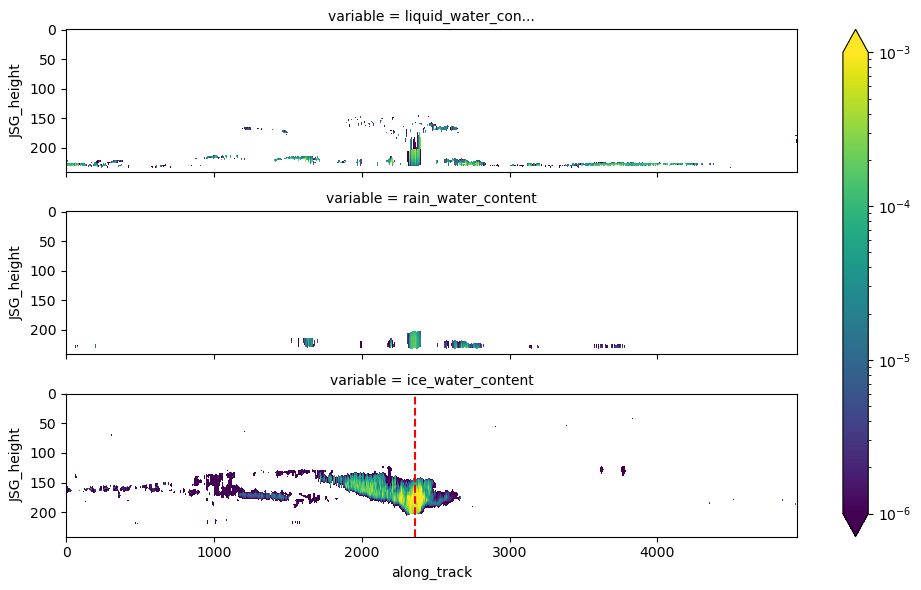

In [228]:
dset[['liquid_water_content', 'rain_water_content', 'ice_water_content']].to_array().plot(
    x='along_track', y='JSG_height', row='variable', yincrease=False, 
    norm=LogNorm(vmin=1e-6, vmax=1e-3),
    figsize=(10, 6),
)
# profile_index = 1605 # low precipitation
profile_index = 2360 # high precipitation
plt.gca().axvline(profile_index, color='red', linestyle='--')

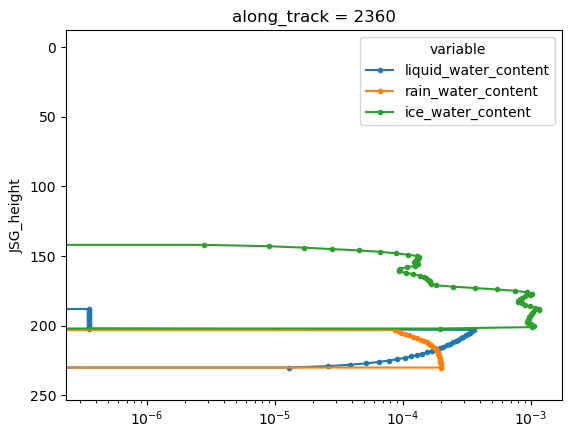

In [229]:
dset.isel(along_track=profile_index)[['liquid_water_content', 'rain_water_content', 'ice_water_content']].to_array().plot(
     y='JSG_height', hue='variable', yincrease=False, xscale='log', marker='.'
)
plt.show()

In [230]:
p_grid = np.logspace(5, 3, 201)
psd_input = dataload.ec_acm_capHydrometeors1D(p_grid=p_grid, dset=dset, ipr=profile_index)

# Liquid

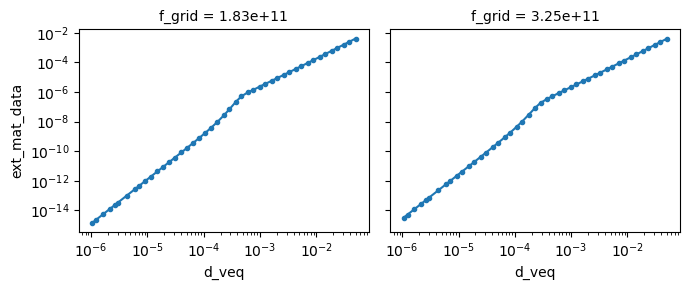

In [281]:
ds_scat = scat_data.import2xarray(
    # '/scratch/li/arts-yang-liquid-simlink', # IR
    # habit='MieSpheres_H2O_liquid', # IR
    dp.single_scattering_database_arts, # MW
    habit='LiquidSphere', # MW
    interpolate_na=True,
)
ds_scat = scat_data.interp_freq_temp(
    ds_scat, 
    # freq=convert.wavelen2freq([10.8e-6]), # IR
    freq=[183e9, 325e9], # MW
    temp=300, # K
    )
ds_scat.sortby('d_veq').ext_mat_data.plot(col='f_grid', x='d_veq', marker = '.', yscale='log', xscale='log', add_legend=False)

In [280]:
ds_scat.d_veq.sortby('d_veq')

<xarray.DataArray 'd_veq' (size: 45)> Size: 360B
array([1.0558760e-06, 1.2429443e-06, 1.6312339e-06, 2.1408232e-06,
       2.6609240e-06, 2.9665952e-06, 4.3405893e-06, 6.0148691e-06,
       7.0805163e-06, 9.2924343e-06, 1.1549978e-05, 1.5158134e-05,
       1.8840715e-05, 2.4726461e-05, 3.0733613e-05, 4.0334641e-05,
       5.0133711e-05, 6.5795232e-05, 8.1779807e-05, 1.0732741e-04,
       1.3340199e-04, 1.7507611e-04, 2.2976901e-04, 2.8559008e-04,
       3.7480700e-04, 4.6586421e-04, 6.1139787e-04, 7.5993348e-04,
       9.9733292e-04, 1.2396292e-03, 1.6268832e-03, 2.0221252e-03,
       2.6538270e-03, 3.2985591e-03, 4.3290126e-03, 5.3807214e-03,
       7.0616320e-03, 8.7772150e-03, 1.1519173e-02, 1.4317690e-02,
       1.8790466e-02, 2.3355502e-02, 3.0651644e-02, 3.8098285e-02,
       5.0000000e-02])
Coordinates:
    d_veq    (size) float64 360B 1.056e-06 1.243e-06 1.631e-06 ... 0.0381 0.05
    d_max    (size) float64 360B 1.056e-06 1.243e-06 1.631e-06 ... 0.0381 0.05
    mass     (size) float64 360B 6.164e-16 1.005e-15 ... 0.02895 0.06545
    d_area   (size) float64 360B 1.056e-06 1.243e-06 1.631e-06 ... 0.0381 0.05
    T_grid   int64 8B 300
Dimensions without coordinates: size

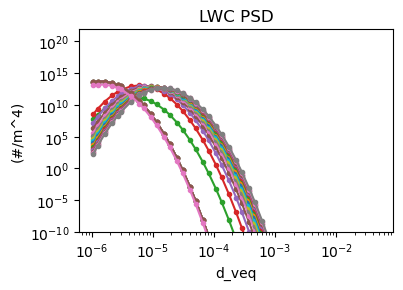

In [285]:
psd = size_dists.acm_cap_lwc(dmeq=ds_scat.d_veq.values, lwc=psd_input['LWC'], ntot=psd_input['LWC_NTOT'])
psd = xr.DataArray(psd, dims=['size', 'pressure'], coords={'d_veq': ds_scat.d_veq, 'pressure':p_grid})
psd.sortby('d_veq').expand_dims('temp').plot(
    col='temp', hue='pressure', x='d_veq', marker='.', 
    yscale='log', xscale='log', add_legend=False)
plt.ylabel('(#/m^4)')
plt.title('LWC PSD')
plt.ylim([1e-10, None])
plt.show()

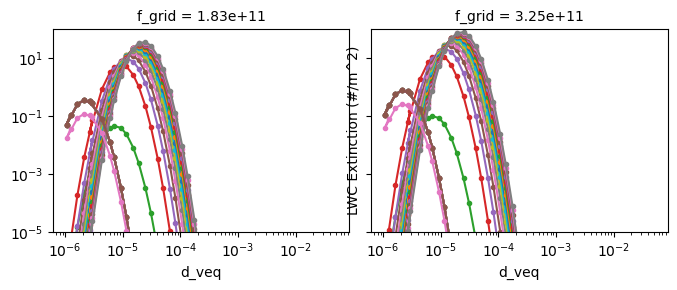

In [293]:
(ds_scat.ext_mat_data * psd).plot(
    col='f_grid', hue='pressure', x='d_veq', marker = '.', 
    yscale='log', xscale='log', add_legend=False)
plt.ylabel('LWC Extinction (#/m^2)')
plt.ylim([1e-5, 1e2])
plt.show()

# Rain

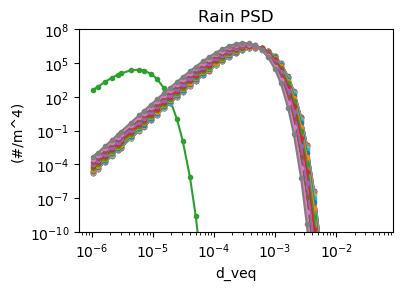

In [298]:
psd = size_dists.acm_cap_rain(d=ds_scat.d_veq.values, d0=psd_input['RWC_D0'], nw=psd_input['RWC_NW'])
psd = xr.DataArray(psd, dims=['size', 'pressure'], coords={'d_veq': ds_scat.d_veq, 'pressure':p_grid})
psd.expand_dims('temp').plot(
    col='temp', hue='pressure', x='d_veq', marker='.', 
    yscale='log', xscale='log', add_legend=False)
plt.ylabel('(#/m^4)')
plt.title('Rain PSD')
plt.ylim([1e-10, 1e8])
plt.show()

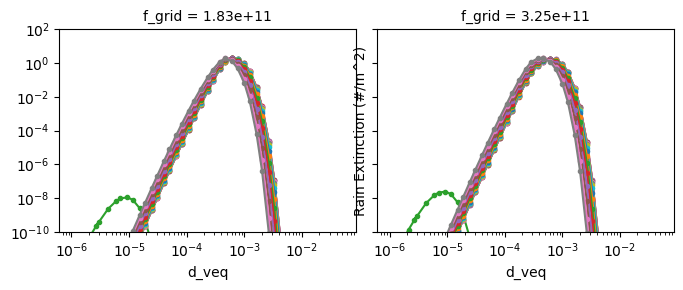

In [302]:
(ds_scat.ext_mat_data * psd).plot(
    col='f_grid', hue='pressure', x='d_veq', marker = '.', 
    yscale='log', xscale='log', add_legend=False)
plt.ylabel('Rain Extinction (#/m^2)')
# plt.title('Bulk extinction of Rain at 10.8 um')
plt.ylim([1e-10, 1e2])
plt.show()

# FWC

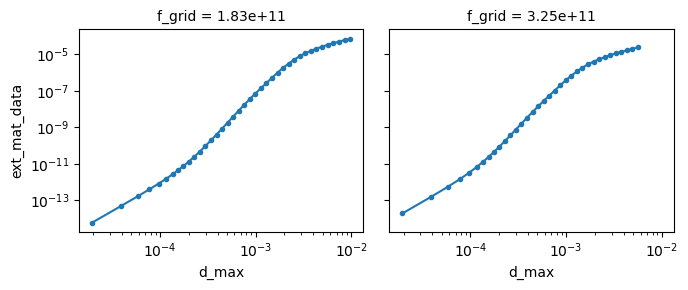

In [314]:
ds_scat = scat_data.import2xarray(
    # '/scratch/li/arts-yang-liquid-simlink', # IR
    # habit="8-ColumnAggregate-ModeratelyRough", # IR
    dp.single_scattering_database_arts,   # MW
    habit="8-ColumnAggregate", # MW
    interpolate_na=False,
)
ds_scat = scat_data.interp_freq_temp(
    ds_scat, 
    # freq=convert.wavelen2freq([10.8e-6]), # IR
    freq=[183e9, 325e9], # MW
    temp=220, # K # MW
    )
ds_scat.ext_mat_data.plot(col='f_grid', x='d_max', marker = '.', yscale='log', xscale='log', add_legend=False)

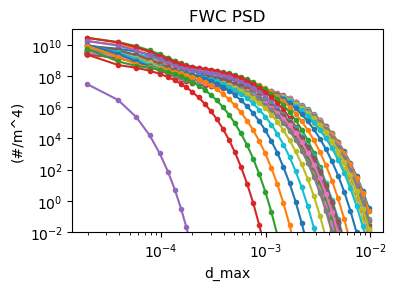

In [316]:
psd = size_dists.acm_cap_fwc(dmax=ds_scat.d_max.values, d0=psd_input['FWC_D0'], n0star=psd_input['FWC_N0STAR'])
psd = xr.DataArray(psd, dims=['size', 'pressure'], coords={'d_max': ds_scat.d_max, 'pressure':p_grid})
psd.expand_dims('temp').plot(col='temp',hue='pressure', x='d_max', marker='.', 
         yscale='log', xscale='log', add_legend=False)
plt.ylabel('(#/m^4)')
plt.title('FWC PSD')
plt.ylim([1e-2, 1e11])
plt.show()

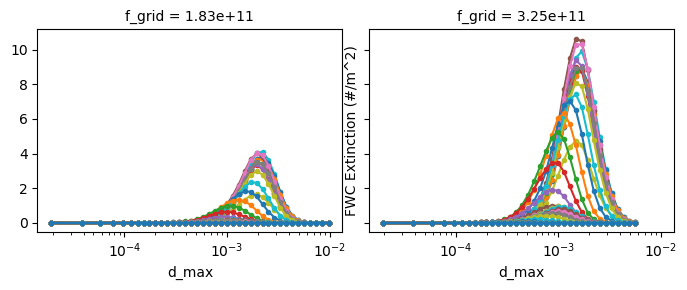

In [318]:
(ds_scat.ext_mat_data * psd).plot(
    col='f_grid', hue='pressure', x='d_max', marker = '.', 
    yscale='linear', xscale='log', add_legend=False)
plt.ylabel('FWC Extinction (#/m^2)')
# plt.ylim([1e-10, 1e2])
plt.show()